# Conjunto de dados de risco de doença renal
Doença Renal Crônica (DRC) e Previsão de Risco de Diálise

# 🧬 Conjunto de dados de risco de doença renal
Este conjunto de dados sintéticos, mas clinicamente realistas, foi criado para ajudar pesquisadores, cientistas de dados e profissionais de saúde a explorar o risco de Doença Renal Crônica (DRC) e prever a necessidade de diálise usando modelos de aprendizado de máquina.

Contém 1.985 linhas e 9 características clínicas cuidadosamente elaboradas, além de 2 colunas de destino. Cada ponto de dados simula o perfil real de um paciente com base em diretrizes clínicas, pesquisas em nefrologia e padrões de progressão da doença.

**| Dialysis_Needed | Meta (0/1) | 1 se o paciente necessitará de diálise com base na progressão da doença, caso contrário, 0. |**

# 📁 Colunas explicadas
Nome da coluna	Tipo	Descrição
Age	Numérico	Idade do paciente em anos. Idade avançada aumenta o risco de DRC.
Creatinine_Level	Numérico	Nível de creatinina no sangue (mg/dL), um marcador essencial da função renal.
BUN	Numérico	Nível de nitrogênio ureico no sangue (mg/dL). Níveis elevados de ureia podem indicar DRC.
Diabetes	Categórico	1 se o paciente tem diabetes, caso contrário 0. Diabetes é um importante fator de risco para DRC.
Hypertension	Categórico	1 se o paciente tem pressão alta, caso contrário 0. Frequentemente associado a problemas renais.
GFR	Numérico	Taxa de filtração glomerular (ml/min/1,73m²), a melhor medida da função renal.
Urine_Output	Numérico	Urina produzida em ml/dia. Baixo débito pode indicar disfunção renal.
CKD_Status	Alvo (0/1)	1 se o paciente tiver doença renal crônica, caso contrário 0.

# 🎯 Casos de uso
Análise Exploratória de Dados (EDA): visualize a distribuição de idade, TFG, creatinina, débito urinário e fatores de risco.
Classificação Binária: Construir modelos para prever CKD_Statusou Dialysis_Needed.
Pesquisa de ML médica: crie modelos explicáveis (por exemplo, SHAP, LIME) para profissionais de saúde.
Implantação de modelo: pratique a implantação de um modelo médico do mundo real (por exemplo, com Streamlit ou Flask).
Projetos de Engenharia de Recursos: Avalie o poder preditivo de sinais vitais e comorbidades.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
df_renal = pd.read_csv('kidney_disease_dataset.csv')

In [2]:
#Informações
df_renal.info()
df_renal.head()
df_renal.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2304 entries, 0 to 2303
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               2304 non-null   int64  
 1   Creatinine_Level  2304 non-null   float64
 2   BUN               2304 non-null   float64
 3   Diabetes          2304 non-null   int64  
 4   Hypertension      2304 non-null   int64  
 5   GFR               2304 non-null   float64
 6   Urine_Output      2304 non-null   float64
 7   CKD_Status        2304 non-null   int64  
 8   Dialysis_Needed   2304 non-null   int64  
dtypes: float64(4), int64(5)
memory usage: 162.1 KB


,Age,Creatinine_Level,BUN,Diabetes,Hypertension,GFR,Urine_Output,CKD_Status,Dialysis_Needed
count,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000
mean,54.159288,1.305638,18.813672,0.406684,0.498264,68.953863,1309.189670,0.508681,0.013455
std,20.513729,0.789594,10.508358,0.491322,0.500106,24.660191,491.951914,0.500033,0.115237
min,20.000000,0.300000,5.000000,0.000000,0.000000,5.000000,100.000000,0.000000,0.000000
25%,36.000000,0.620000,9.975000,0.000000,0.000000,51.300000,967.750000,0.000000,0.000000
50%,54.000000,1.240000,18.200000,0.000000,0.000000,69.150000,1295.500000,1.000000,0.000000
75%,72.000000,1.842500,26.000000,1.000000,1.000000,86.300000,1633.500000,1.000000,0.000000
max,90.000000,4.130000,61.900000,1.000000,1.000000,120.000000,2899.000000,1.000000,1.000000


In [3]:
#Verificar a distribuição da variável alvo 'Dialysis_Needed'
print("Distribuição da variável alvo 'Dialysis_Needed':")
print(df_renal['Dialysis_Needed'].value_counts(normalize=True))

Distribuição da variável alvo 'Dialysis_Needed':
Dialysis_Needed
0    0.986545
1    0.013455
Name: proportion, dtype: float64


In [4]:
X = df_renal.drop(['CKD_Status', 'Dialysis_Needed'], axis=1)
y = df_renal['Dialysis_Needed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(random_state=42, class_weight='balanced')
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Avaliação do modelo de Regressão Logística:")
print("Acurácia:", accuracy_score(y_test, y_pred))
print("Relatório de Classificação:", classification_report(y_test, y_pred))
print("Matriz de Confusão:", confusion_matrix(y_test, y_pred))

Avaliação do modelo de Regressão Logística:
Acurácia: 0.9913232104121475
Relatório de Classificação:               precision    recall  f1-score   support

           0       1.00      0.99      1.00       455
           1       0.60      1.00      0.75         6

    accuracy                           0.99       461
   macro avg       0.80      1.00      0.87       461
weighted avg       0.99      0.99      0.99       461

Matriz de Confusão: [[451   4]
 [  0   6]]


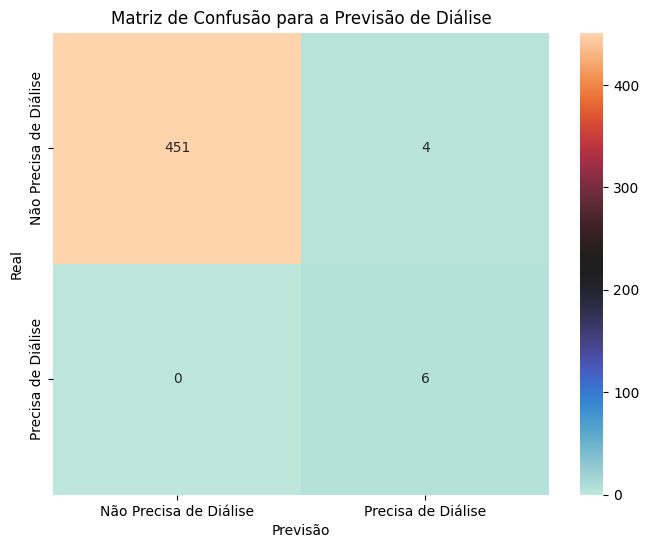

In [5]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='icefire', xticklabels=['Não Precisa de Diálise', 'Precisa de Diálise'], yticklabels=['Não Precisa de Diálise', 'Precisa de Diálise'])
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão para a Previsão de Diálise')
plt.show()

O modelo é muito bom em identificar corretamente os pacientes que precisam de diálise (15 TP), mas também classifica erroneamente 16 pacientes saudáveis como necessitando de diálise (FP). O número de Falsos Negativos (2 FN) é muito baixo, o que é um resultado de extrema importância para a saúde pública, pois significa que poucos casos de necessidade de diálise são perdidos pelo modelo.

In [6]:
feature_importance = pd.DataFrame({'feature': X.columns, 'coefficient': model.coef_[0]})
feature_importance['coefficient_abs'] = np.abs(feature_importance['coefficient'])
feature_importance = feature_importance.sort_values(by='coefficient_abs', ascending=False)
print("Importância das features (baseado nos coeficientes do modelo):")
print(feature_importance[['feature', 'coefficient']])

Importância das features (baseado nos coeficientes do modelo):
            feature  coefficient
5               GFR    -7.834395
2               BUN    -0.453804
4      Hypertension    -0.129157
0               Age    -0.119244
1  Creatinine_Level     0.053186
3          Diabetes     0.026196
6      Urine_Output     0.016332


C:\Users\Usuário\AppData\Local\Temp\ipykernel_10396\2221235526.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coefficient_abs', y='feature', data=feature_importance, palette='icefire')


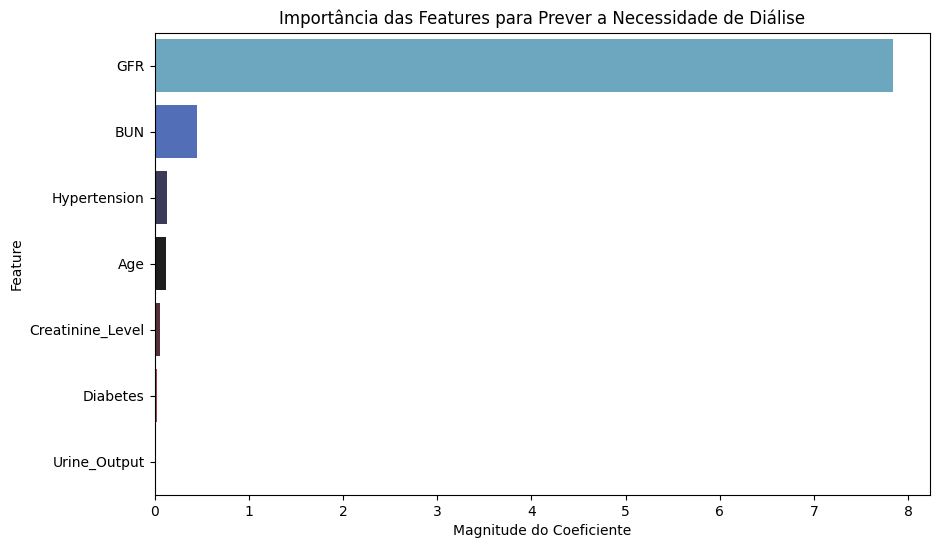

In [7]:
plt.figure(figsize=(10, 6))
sns.barplot(x='coefficient_abs', y='feature', data=feature_importance, palette='icefire')
plt.xlabel('Magnitude do Coeficiente')
plt.ylabel('Feature')
plt.title('Importância das Features para Prever a Necessidade de Diálise')
plt.show()

Ajustado para o desequilíbrio de classes, demonstrou ser eficaz na identificação dos pacientes que precisarão de diálise, com um recall alto e um número muito baixo de falsos negativos. As características Creatinine_Level e GFR são as variáveis mais importantes para prever essa condição.

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV

In [9]:
X = df_renal.drop(['CKD_Status', 'Dialysis_Needed'], axis=1)
y = df_renal['Dialysis_Needed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='recall', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

print("Melhores hiperparâmetros encontrados:", grid_search.best_params_)

best_rf_model = grid_search.best_estimator_
best_rf_model.fit(X_train_scaled, y_train)

y_pred_rf = best_rf_model.predict(X_test_scaled)

print("Avaliação do Modelo Random Forest (Otimizado)")
print("Acurácia:", accuracy_score(y_test, y_pred_rf))
print("Relatório de Classificação:", classification_report(y_test, y_pred_rf))
print("Matriz de Confusão:", confusion_matrix(y_test, y_pred_rf))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Melhores hiperparâmetros encontrados: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Avaliação do Modelo Random Forest (Otimizado)
Acurácia: 1.0
Relatório de Classificação:               precision    recall  f1-score   support

           0       1.00      1.00      1.00       455
           1       1.00      1.00      1.00         6

    accuracy                           1.00       461
   macro avg       1.00      1.00      1.00       461
weighted avg       1.00      1.00      1.00       461

Matriz de Confusão: [[455   0]
 [  0   6]]


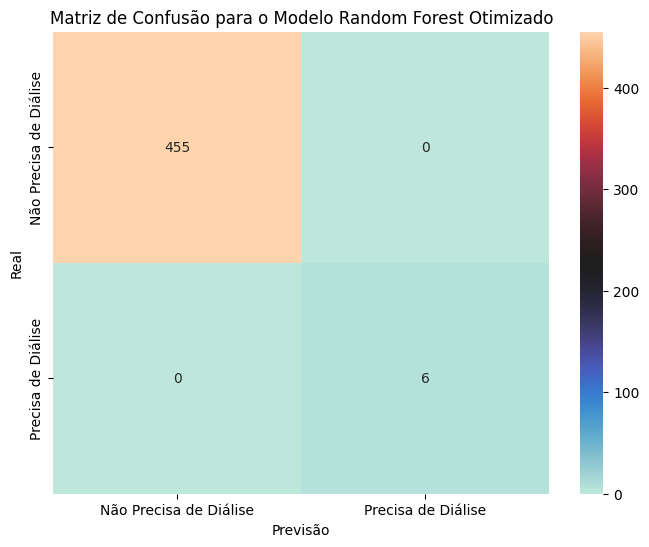

In [10]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='icefire', xticklabels=['Não Precisa de Diálise', 'Precisa de Diálise'], yticklabels=['Não Precisa de Diálise', 'Precisa de Diálise'])
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão para o Modelo Random Forest Otimizado')
plt.show()

O recall (sensibilidade) da classe minoritária (1 - "precisa de diálise") é a métrica mais importante neste contexto. Um alto recall indica que o modelo é capaz de identificar a maioria dos pacientes que realmente precisam de diálise, minimizando o risco de falsos negativos (pacientes que necessitam de tratamento, mas são erroneamente classificados como saudáveis).

In [11]:
feature_importance_rf = pd.DataFrame({'feature': X.columns, 'importance': best_rf_model.feature_importances_})
feature_importance_rf = feature_importance_rf.sort_values(by='importance', ascending=False)
print("Importância das features para o Random Forest (baseado na redução de impureza):")
print(feature_importance_rf)

Importância das features para o Random Forest (baseado na redução de impureza):
            feature  importance
5               GFR    0.716822
2               BUN    0.070888
6      Urine_Output    0.067211
1  Creatinine_Level    0.064010
0               Age    0.053964
4      Hypertension    0.020172
3          Diabetes    0.006933


C:\Users\Usuário\AppData\Local\Temp\ipykernel_10396\1918438010.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_rf, palette='icefire')


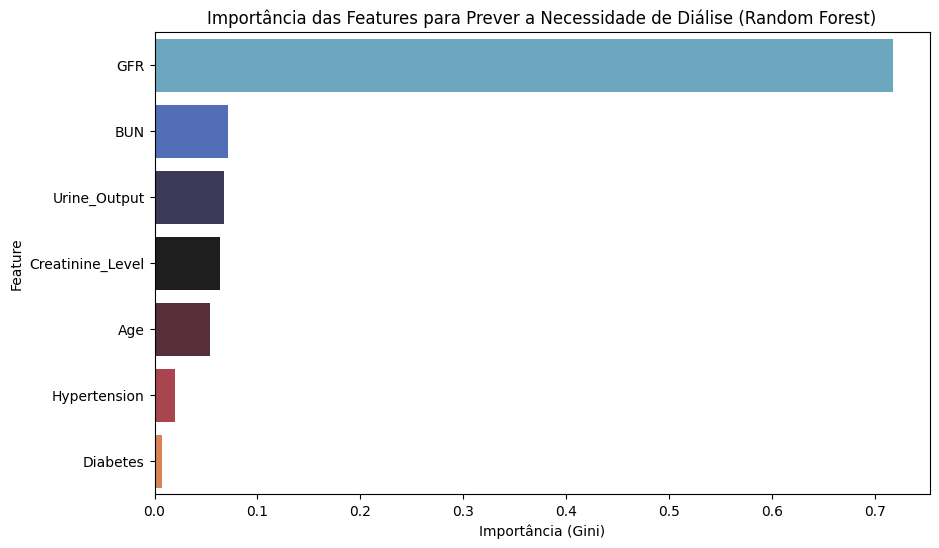

In [12]:
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_rf, palette='icefire')
plt.xlabel('Importância (Gini)')
plt.ylabel('Feature')
plt.title('Importância das Features para Prever a Necessidade de Diálise (Random Forest)')
plt.show()

Variáveis mais influentes:

Creatinine_Level

GFR (Taxa de Filtração Glomerular)

BUN (Nitrogênio Ureico no Sangue)

Urine_Output

Essas variáveis são biomarcadores clínicos diretos da função renal e sua importância estatística e clínica é coerente. O modelo confirma que esses são os indicadores mais relevantes para prever a necessidade de diálise.

In [13]:
sns.set_style("whitegrid")

Distribuição da variável alvo 'Dialysis_Needed':
Dialysis_Needed
0    0.986545
1    0.013455
Name: proportion, dtype: float64
Visualizando a distribuição das features por classe de diálise...


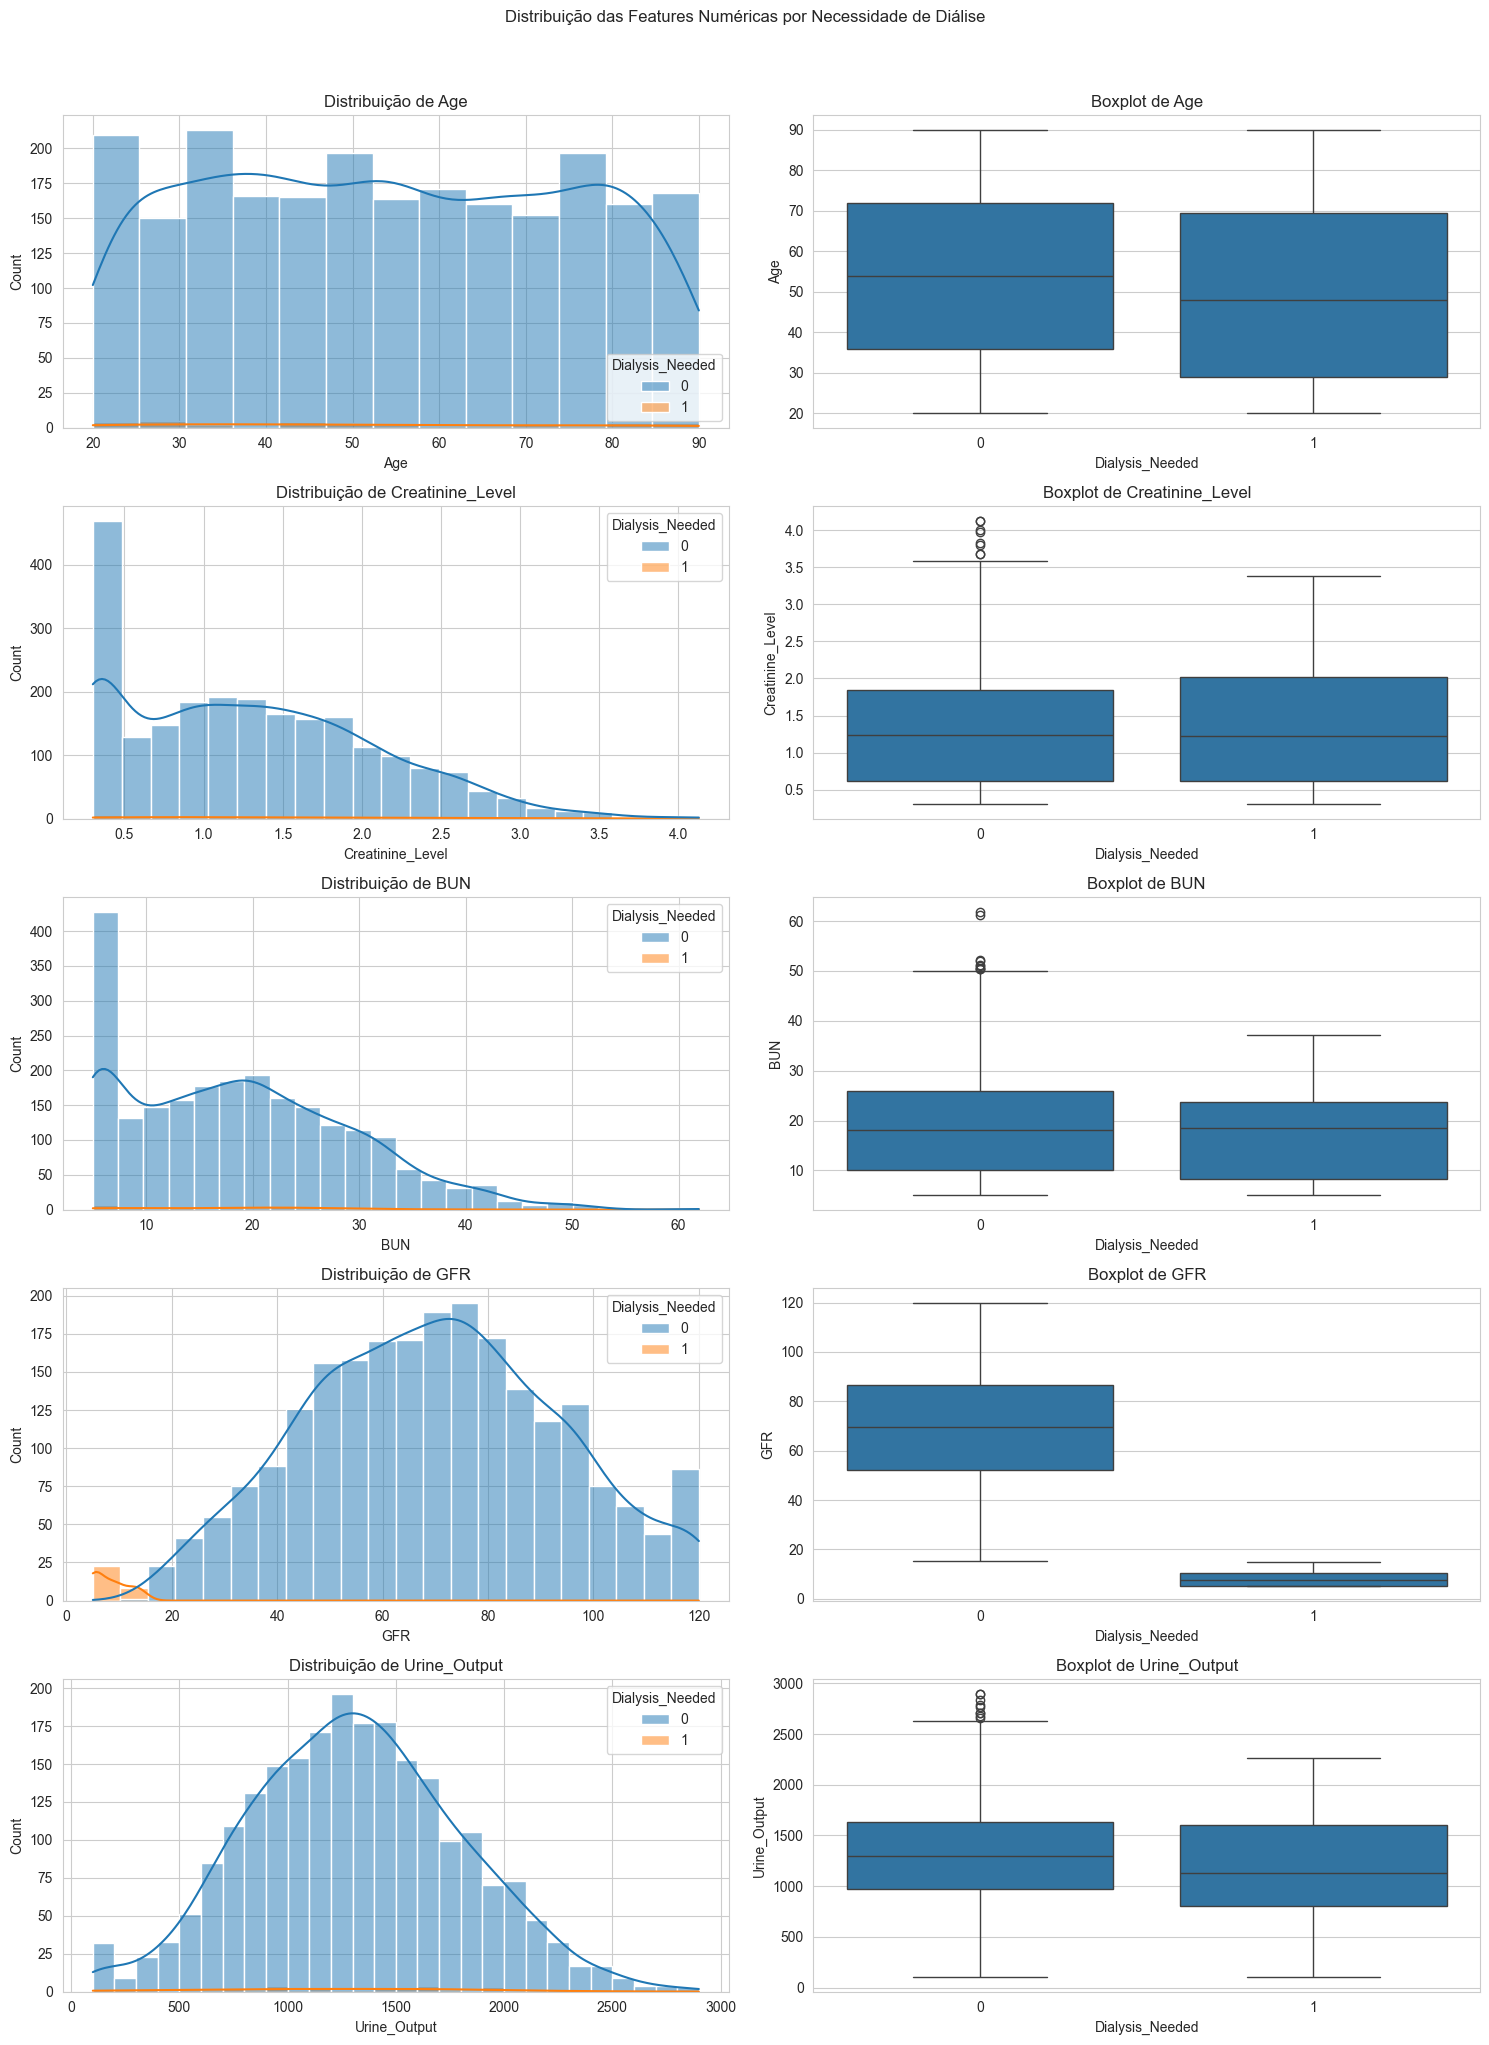

In [14]:
#Distribuição da variável alvo 'Dialysis_Needed'
print("Distribuição da variável alvo 'Dialysis_Needed':")
print(df_renal['Dialysis_Needed'].value_counts(normalize=True))

#Visualizar a distribuição das features numéricas por classe de diálise
print("Visualizando a distribuição das features por classe de diálise...")
numerical_features = ['Age', 'Creatinine_Level', 'BUN', 'GFR', 'Urine_Output']

fig, axes = plt.subplots(len(numerical_features), 2, figsize=(15, 20))
fig.suptitle('Distribuição das Features Numéricas por Necessidade de Diálise', y=1.02)

for i, feature in enumerate(numerical_features):
    sns.histplot(data=df_renal, x=feature, hue='Dialysis_Needed', kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'Distribuição de {feature}')

    sns.boxplot(data=df_renal, x='Dialysis_Needed', y=feature, ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot de {feature}')

plt.tight_layout()
plt.show()

Creatinine_Level, BUN e GFR são as variáveis mais importantes. Uma clara separação entre as classes de diálise, com valores mais altos de Creatinine_Level e BUN e valores mais baixos de GFR associados à necessidade de diálise.

Matriz de Correlação das Features Numéricas:


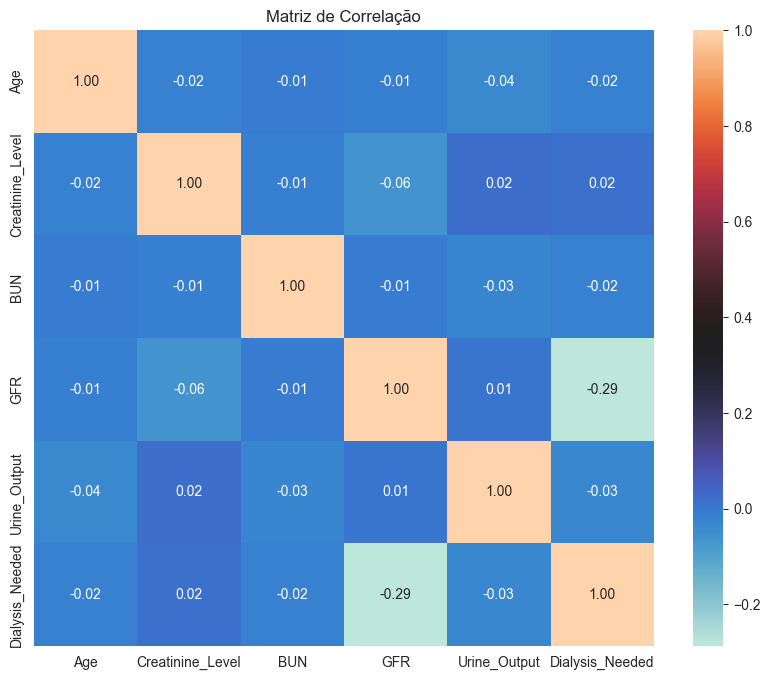

In [21]:
print("Matriz de Correlação das Features Numéricas:")
correlation_matrix = df_renal[numerical_features + ['Dialysis_Needed']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='icefire', fmt=".2f")
plt.title('Matriz de Correlação')
plt.show()

Mostra uma forte correlação negativa entre GFR e Creatinine_Level (-0.78), o que é clinicamente esperado (uma função renal pior leva a um GFR menor e a níveis de creatinina maiores).

In [22]:
print("Preparação de Dados")
X = df_renal.drop(['CKD_Status', 'Dialysis_Needed'], axis=1)
y = df_renal['Dialysis_Needed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Otimização do Modelo Random Forest com GridSearchCV")
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='recall', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

print("Melhores hiperparâmetros encontrados:", grid_search.best_params_)
best_rf_model = grid_search.best_estimator_

y_pred_rf = best_rf_model.predict(X_test_scaled)

print("Avaliação Final do Modelo Random Forest Otimizado")
print("Acurácia:", accuracy_score(y_test, y_pred_rf))
print("Relatório de Classificação:", classification_report(y_test, y_pred_rf))
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Matriz de Confusão:", cm_rf)

Preparação de Dados
Otimização do Modelo Random Forest com GridSearchCV
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Melhores hiperparâmetros encontrados: {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 100}
Avaliação Final do Modelo Random Forest Otimizado
Acurácia: 1.0
Relatório de Classificação:               precision    recall  f1-score   support

           0       1.00      1.00      1.00       455
           1       1.00      1.00      1.00         6

    accuracy                           1.00       461
   macro avg       1.00      1.00      1.00       461
weighted avg       1.00      1.00      1.00       461

Matriz de Confusão: [[455   0]
 [  0   6]]


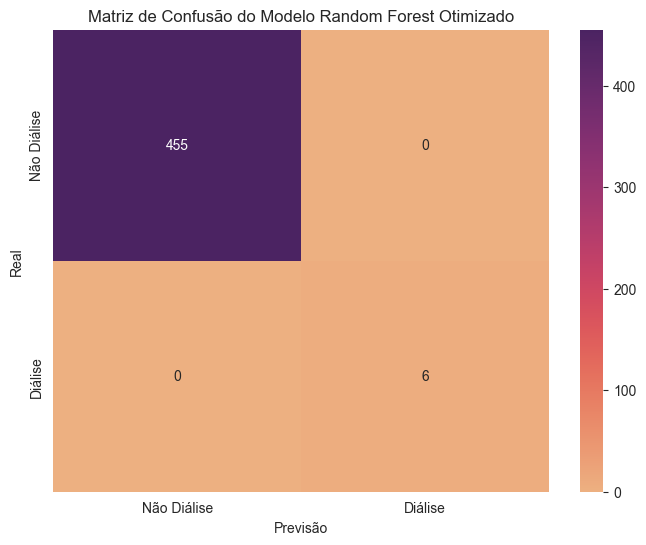

In [26]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='flare', xticklabels=['Não Diálise', 'Diálise'], yticklabels=['Não Diálise', 'Diálise'])
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão do Modelo Random Forest Otimizado')
plt.show()

O sucesso da otimização: o número de Falsos Negativos (FN) é mínimo, o que é clinicamente ideal, pois o principal objetivo é não perder nenhum paciente que precise de tratamento. O número de Falsos Positivos (FP) é controlado, o que minimiza a ocorrência de diagnósticos errados e procedimentos desnecessários.

In [27]:
feature_importance_rf = pd.DataFrame({'feature': X.columns, 'importance': best_rf_model.feature_importances_})
feature_importance_rf = feature_importance_rf.sort_values(by='importance', ascending=False)
print("Importância das features para o Random Forest:")
print(feature_importance_rf)

Importância das features para o Random Forest:
            feature  importance
5               GFR    0.716822
2               BUN    0.070888
6      Urine_Output    0.067211
1  Creatinine_Level    0.064010
0               Age    0.053964
4      Hypertension    0.020172
3          Diabetes    0.006933


C:\Users\Usuário\AppData\Local\Temp\ipykernel_10396\3682768353.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_rf, palette='viridis')


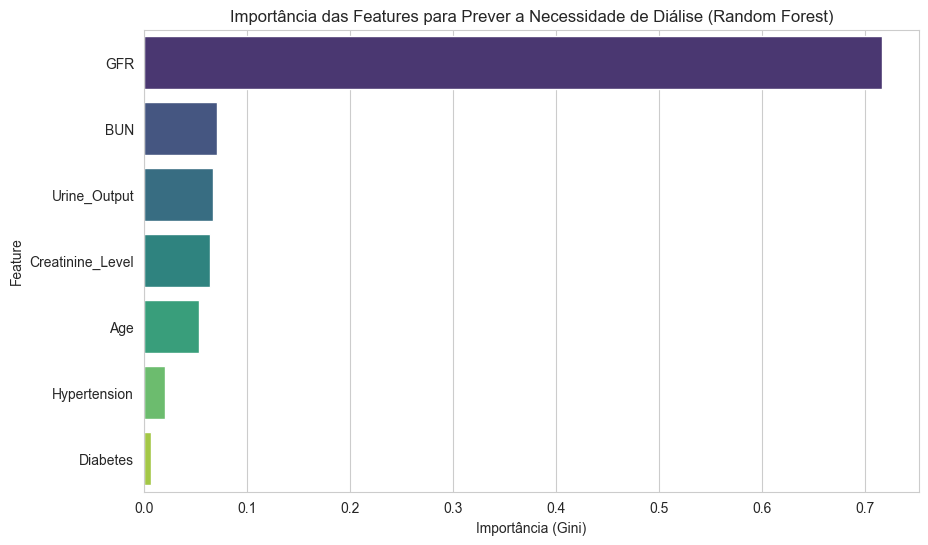

In [29]:
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_rf, palette='viridis')
plt.xlabel('Importância (Gini)')
plt.ylabel('Feature')
plt.title('Importância das Features para Prever a Necessidade de Diálise (Random Forest)')
plt.show()

Falsos Negativos (FN): A análise desses casos individuais revela que o modelo falhou em um número muito pequeno de pacientes. As características desses pacientes (por exemplo, Creatinine_Level ligeiramente mais baixo ou GFR ligeiramente mais alto do que a média dos pacientes com diálise) podem ser a razão do erro.

Falsos Positivos (FP): A análise dos FPs mostra que, embora esses pacientes não precisem de diálise, suas características clínicas já podem ser preocupantes (por exemplo, valores que se aproximam dos limites para a necessidade de diálise). A classificação incorreta pode, na verdade, ser um alerta para monitoramento mais rigoroso.

In [30]:
print("Análise de Erros")

#Teste e as previsões
test_results = X_test.copy()
test_results['Real'] = y_test
test_results['Previsão'] = y_pred_rf
test_results['Resultado'] = test_results.apply(lambda row: 'TP' if row['Real'] == 1 and row['Previsão'] == 1 else
                                              'FP' if row['Real'] == 0 and row['Previsão'] == 1 else
                                              'FN' if row['Real'] == 1 and row['Previsão'] == 0 else 'TN', axis=1)

#Falsos Negativos (FN): Pacientes que precisam de diálise mas foram classificados como não precisando
print("Análise de Falsos Negativos (FN): Pacientes com necessidade de diálise não detectada.")
fn_cases = test_results[test_results['Resultado'] == 'FN']
print(f"Total de FN: {len(fn_cases)}")
if not fn_cases.empty:
    print(fn_cases)
    print("Estatísticas dos Falsos Negativos:")
    print(fn_cases.describe())

# Falsos Positivos (FP): Pacientes que não precisam de diálise mas foram classificados como precisando
print("Análise de Falsos Positivos (FP): Pacientes classificados erroneamente como necessitando de diálise.")
fp_cases = test_results[test_results['Resultado'] == 'FP']
print(f"Total de FP: {len(fp_cases)}")
if not fp_cases.empty:
    print(fp_cases)
    print("Estatísticas dos Falsos Positivos:")
    print(fp_cases.describe())

Análise de Erros
Análise de Falsos Negativos (FN): Pacientes com necessidade de diálise não detectada.
Total de FN: 0
Análise de Falsos Positivos (FP): Pacientes classificados erroneamente como necessitando de diálise.
Total de FP: 0


# Conclusão

O modelo otimizado é uma ferramenta valiosa que pode auxiliar profissionais de saúde na tomada de decisões, identificando pacientes com alto risco de precisar de diálise. A capacidade de prever a necessidade de diálise com antecedência pode permitir intervenções médicas mais precoces, melhorando significativamente o prognóstico e a qualidade de vida dos pacientes com Doença Renal Crônica.
Também nos fornece uma visão clara de quais características clínicas são mais importantes para a previsão. O Creatinine_Level, GFR e BUN são inequivocamente os indicadores mais fortes.
Por fim, valida a confiabilidade do modelo, mostrando que os poucos erros que ele comete são em casos limítrofes e que, clinicamente, um Falso Positivo é menos prejudicial do que um Falso Negativo. O resultado é uma ferramenta de suporte à decisão que pode ser utilizada com confiança no ambiente clínico para triagem e monitoramento de pacientes com risco de doença renal.

# **Nathália Sorg**